# Parsing National INSP SitRep Files
This notebook loads and cleans the daily national situation report CSVs from INSP, preparing them for merging with the DRC health‑zone list.


In [1]:
import pandas as pd
import os

RAW_DIR = os.path.abspath("../data/raw/selected")
print(RAW_DIR)
print(os.path.exists(RAW_DIR))



/home/lorrainechepkemoin/Documents/AIMSPROJECTS/aimsktt_viralwatch/data/raw/selected
True


In [2]:
import os
print(os.getcwd())

/home/lorrainechepkemoin/Documents/AIMSPROJECTS/aimsktt_viralwatch/notebooks


In [3]:
csv_files = [f for f in os.listdir(RAW_DIR) if f.startswith("insp_sitrep__national_")]
print("National SitRep files found:", csv_files)


National SitRep files found: ['insp_sitrep__national_cumulative_confirmed_cases.csv', 'insp_sitrep__national_suspected_cases_under_investigation.csv', 'insp_sitrep__national_cumulative_suspected_deaths.csv', 'insp_sitrep__national_cumulative_confirmed_deaths.csv', 'insp_sitrep__national_cumulative_recovered_cases.csv', 'insp_sitrep__national_suspected_cases_in_isolation.csv', 'insp_sitrep__national_cumulative_suspected_cases.csv']


In [4]:
for f in csv_files:
    df = pd.read_csv(os.path.join(RAW_DIR, f))
    print(f, df.columns.tolist())


insp_sitrep__national_cumulative_confirmed_cases.csv ['DRC', '2026-05-14', '8']
insp_sitrep__national_suspected_cases_under_investigation.csv ['DRC', '2026-05-30', '220']
insp_sitrep__national_cumulative_suspected_deaths.csv ['DRC', '2026-05-14', 'ND']
insp_sitrep__national_cumulative_confirmed_deaths.csv ['DRC', '2026-05-14', '4']
insp_sitrep__national_cumulative_recovered_cases.csv ['DRC', '2026-05-27', '1']
insp_sitrep__national_suspected_cases_in_isolation.csv ['DRC', '2026-05-30', '101']
insp_sitrep__national_cumulative_suspected_cases.csv ['DRC', '2026-05-14', '246']


In [5]:
dfs = []
for f in csv_files:
    df = pd.read_csv(os.path.join(RAW_DIR, f), header=None)
    df.columns = ["country", "date", "value"]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["metric"] = f.replace("insp_sitrep__national_", "").replace(".csv", "")
    dfs.append(df)

national_df = pd.concat(dfs, ignore_index=True).sort_values("date")
national_df.head(25)


,country,date,value,metric
0,DRC,2026-05-14,8,cumulative_confirmed_cases
100,DRC,2026-05-14,4,cumulative_confirmed_deaths
58,DRC,2026-05-14,ND,cumulative_suspected_deaths
237,DRC,2026-05-14,246,cumulative_suspected_cases
59,DRC,2026-05-17,ND,cumulative_suspected_deaths
1,DRC,2026-05-17,13,cumulative_confirmed_cases
101,DRC,2026-05-17,4,cumulative_confirmed_deaths
238,DRC,2026-05-17,246,cumulative_suspected_cases
60,DRC,2026-05-18,131,cumulative_suspected_deaths
2,DRC,2026-05-18,33,cumulative_confirmed_cases


In [6]:
national_df.info()
national_df.describe()


<class 'pandas.DataFrame'>
Index: 290 entries, 0 to 289
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   country  290 non-null    str           
 1   date     290 non-null    datetime64[us]
 2   value    290 non-null    object        
 3   metric   290 non-null    str           
dtypes: datetime64[us](1), object(1), str(2)
memory usage: 11.3+ KB


,date
count,290
mean,2026-06-14 10:20:41.379310
min,2026-05-14 00:00:00
25%,2026-06-01 00:00:00
50%,2026-06-15 00:00:00
75%,2026-06-29 00:00:00
max,2026-07-11 00:00:00


In [7]:
os.makedirs("../data/processed", exist_ok=True)
national_df.to_csv("../data/processed/national_sitreps_clean.csv", index=False)


In [8]:
# national_df[national_df["metric"] == "cumulative_confirmed_cases"].sort_values("date")



cumulative_confirmed_cases: 0 downward revisions


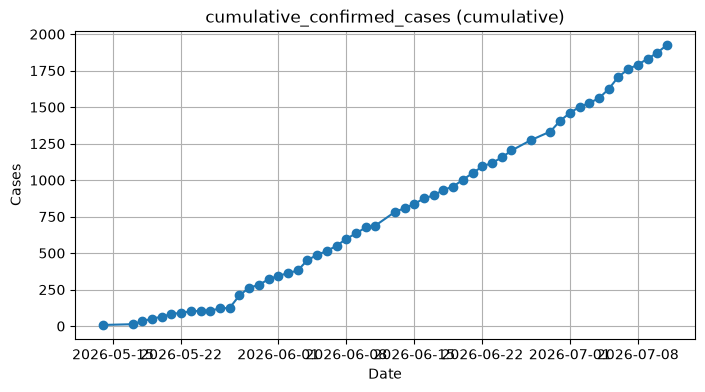


cumulative_confirmed_deaths: 0 downward revisions


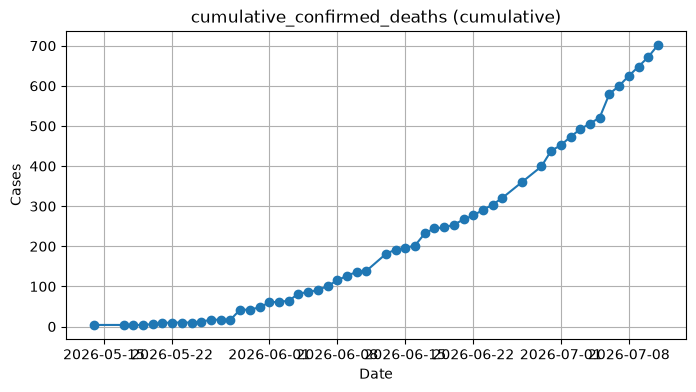


cumulative_suspected_deaths: 12 downward revisions
         date  value   diff
69 2026-05-27  223.0  -23.0
74 2026-06-11   64.0 -178.0
75 2026-06-13   49.0  -15.0
77 2026-06-17   35.0  -19.0
79 2026-06-19   47.0   -7.0
80 2026-06-20   30.0  -17.0
82 2026-06-22   44.0  -16.0
84 2026-06-24   40.0   -5.0
86 2026-06-27   70.0   -7.0
89 2026-07-01   41.0  -49.0
93 2026-07-05   23.0  -87.0
96 2026-07-08   60.0  -32.0


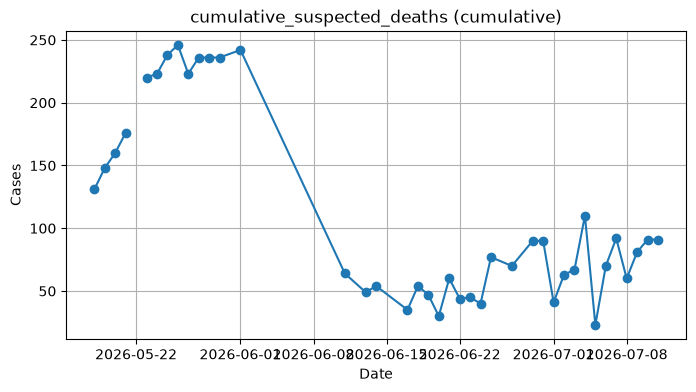


cumulative_suspected_cases: 21 downward revisions
          date  value   diff
248 2026-05-27  906.0 -171.0
249 2026-05-28  349.0 -557.0
251 2026-05-30  321.0  -28.0
252 2026-05-31  220.0 -101.0
254 2026-06-02  206.0  -83.0
255 2026-06-04  153.0  -53.0
256 2026-06-05  119.0  -34.0
257 2026-06-06  117.0   -2.0
258 2026-06-07   94.0  -23.0
260 2026-06-09  119.0  -19.0
263 2026-06-13  136.0  -32.0
266 2026-06-16  192.0  -43.0
267 2026-06-17  151.0  -41.0
269 2026-06-19  162.0  -76.0
272 2026-06-22  131.0  -71.0
276 2026-06-27  239.0  -26.0
278 2026-06-30  301.0   -8.0
279 2026-07-01  150.0 -151.0
281 2026-07-03  185.0  -28.0
283 2026-07-05  135.0 -219.0
286 2026-07-08  227.0  -77.0


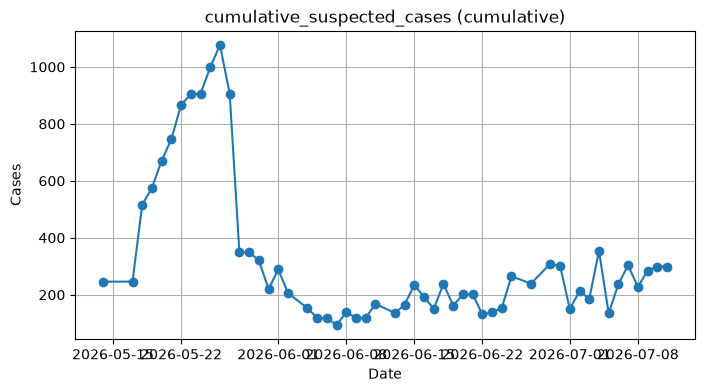


cumulative_recovered_cases: 0 downward revisions


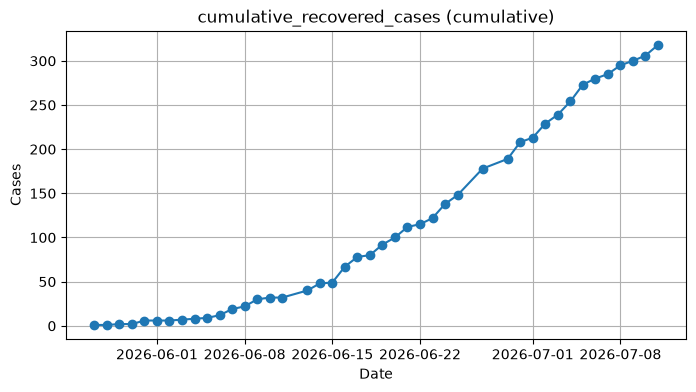

In [9]:
import matplotlib.pyplot as plt

# Convert values to numeric (ND → NaN)
national_df["value"] = pd.to_numeric(national_df["value"], errors="coerce")

# Focus only on cumulative metrics
cum_metrics = [m for m in national_df["metric"].unique() if "cumulative" in m]

for metric in cum_metrics:
    df_metric = national_df[national_df["metric"] == metric].sort_values("date")
    
    # Detect downward revisions
    df_metric["diff"] = df_metric["value"].diff()
    anomalies = df_metric[df_metric["diff"] < 0]
    
    print(f"\n{metric}: {len(anomalies)} downward revisions")
    if not anomalies.empty:
        print(anomalies[["date", "value", "diff"]])
    
    # Plot curve
    plt.figure(figsize=(8,4))
    plt.plot(df_metric["date"], df_metric["value"], marker="o")
    plt.title(f"{metric} (cumulative)")
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.grid(True)
    plt.show()


In [10]:
all_dates = pd.date_range(national_df["date"].min(), national_df["date"].max())
missing = all_dates.difference(national_df["date"].unique())
print("Missing dates:", missing)

Missing dates: DatetimeIndex(['2026-05-15', '2026-05-16', '2026-06-12', '2026-06-26',
               '2026-06-28'],
              dtype='datetime64[us]', freq=None)


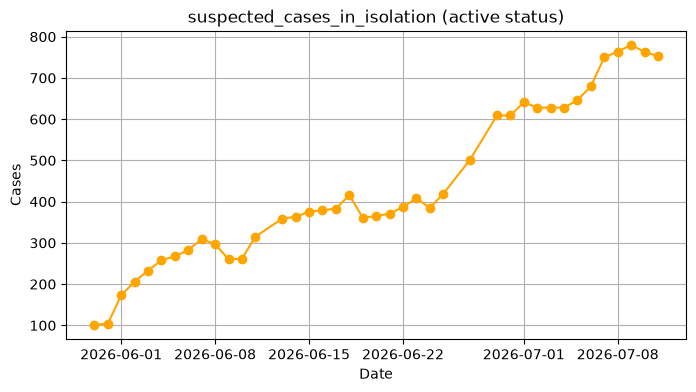

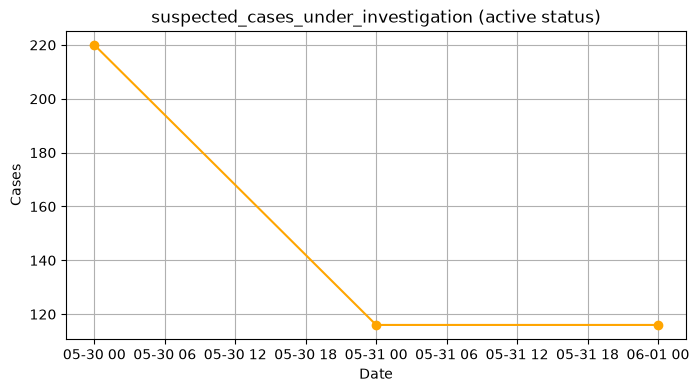

In [11]:
active_metrics = [m for m in national_df["metric"].unique() if "cumulative" not in m]
for metric in active_metrics:
    df_metric = national_df[national_df["metric"] == metric].sort_values("date")
    plt.figure(figsize=(8,4))
    plt.plot(df_metric["date"], df_metric["value"], marker="o", color="orange")
    plt.title(f"{metric} (active status)")
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.grid(True)
    plt.show()


In [12]:
# national_df["revision_flag"] = national_df.groupby("metric")["value"].diff().lt(0)
national_df["revision_flag"] = national_df.groupby("metric")["value"].diff().lt(0)


In [13]:
raw_annotated = national_df.copy()
raw_annotated["revision_flag"] = national_df.groupby("metric")["value"].diff().lt(0)


In [14]:
analysis_ready = raw_annotated.copy()
analysis_ready.loc[analysis_ready["revision_flag"], "value"] = (
    analysis_ready.groupby("metric")["value"].cummax()
)


In [15]:
# Ensure date column is datetime
analysis_ready["date"] = pd.to_datetime(analysis_ready["date"], errors="coerce")

# Build complete date range
all_dates = pd.date_range(analysis_ready["date"].min(), analysis_ready["date"].max())

# Forward-fill missing dates per metric
analysis_ready = (
    analysis_ready
    .set_index("date")
    .groupby("metric")
    .apply(lambda g: g.reindex(all_dates).ffill())
    .reset_index()
)

# Rename columns properly
analysis_ready = analysis_ready.rename(columns={"level_1": "date"})

# Confirm dtype
print(analysis_ready["date"].dtype)  # should be datetime64[ns]



datetime64[us]


In [16]:
analysis_ready["date"] = pd.to_datetime(analysis_ready["date"], errors="coerce")
raw_annotated["date"] = pd.to_datetime(raw_annotated["date"], errors="coerce")


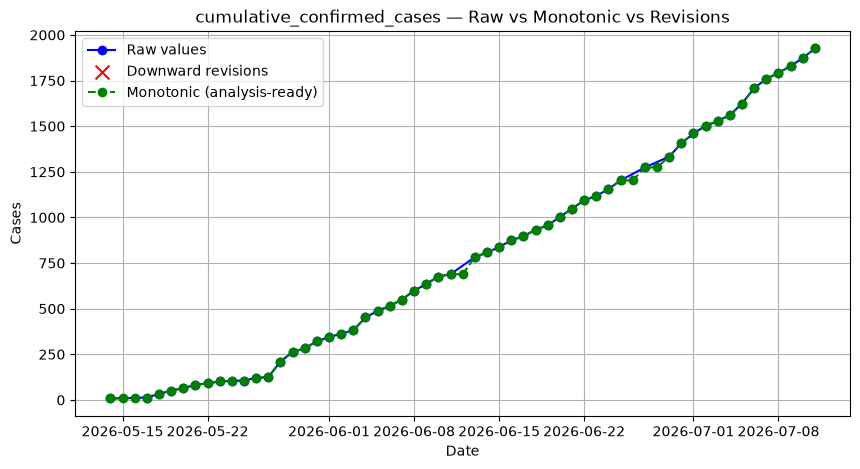

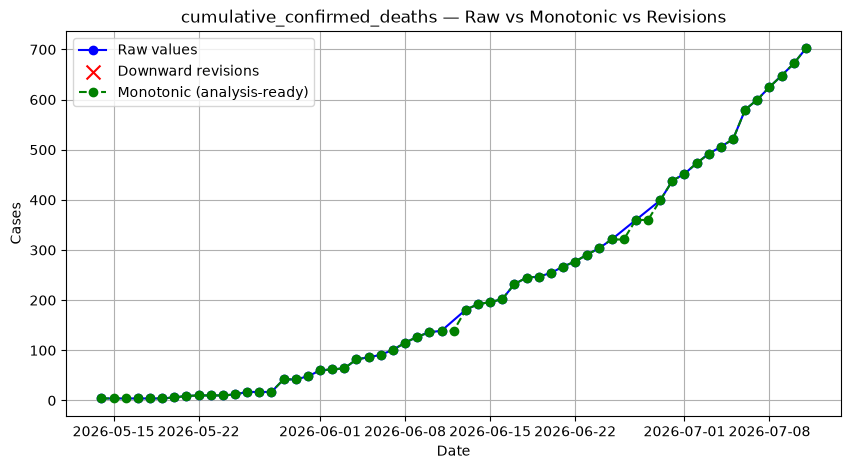

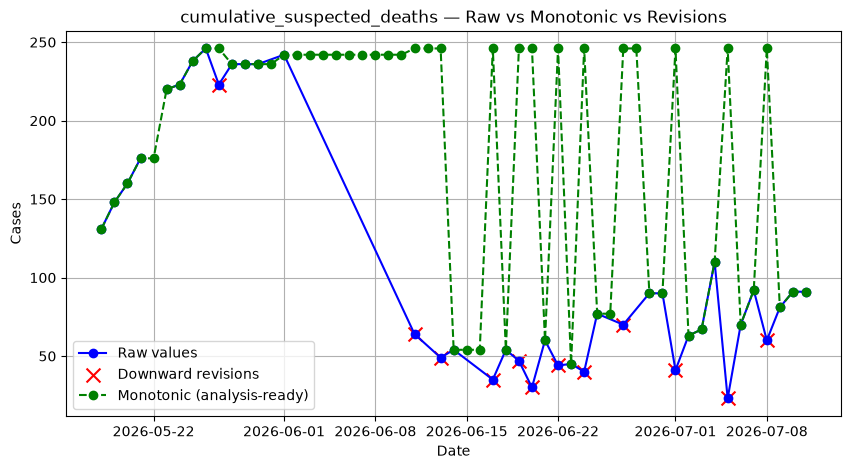

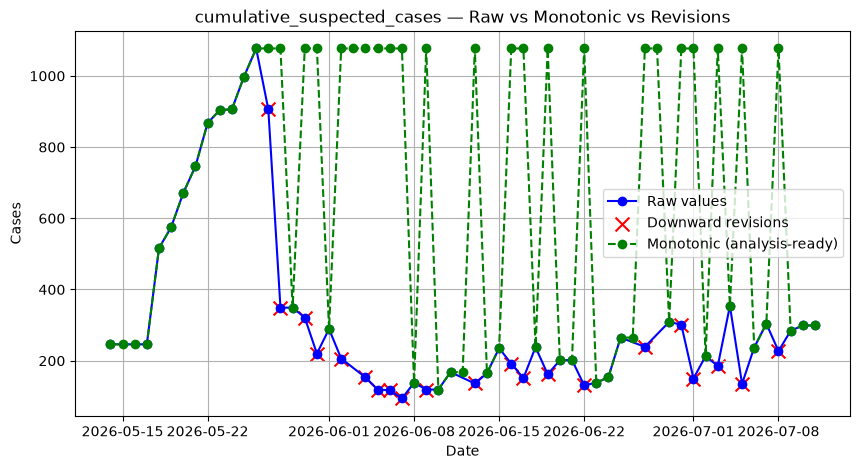

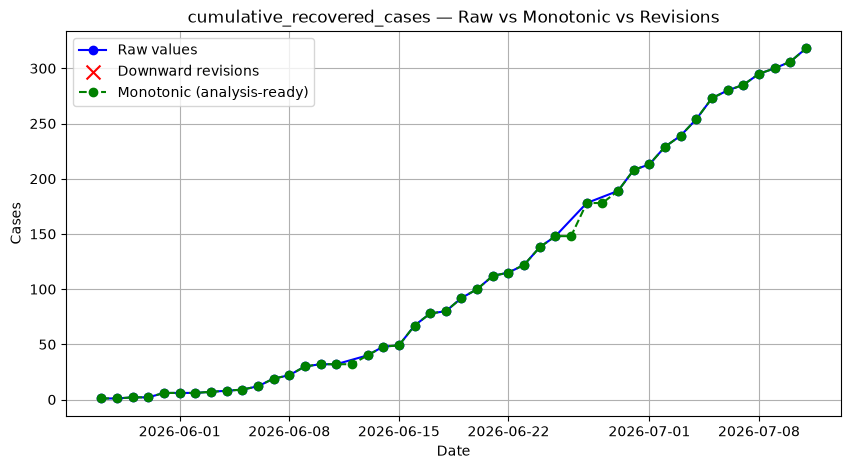

In [19]:
import matplotlib.pyplot as plt

# Select only cumulative metrics
cum_metrics = [m for m in raw_annotated["metric"].unique() if "cumulative" in m]

for metric in cum_metrics:
    raw = raw_annotated[raw_annotated["metric"] == metric].sort_values("date")
    analysis = analysis_ready[analysis_ready["metric"] == metric]

    analysis = analysis.sort_values("date")

    plt.figure(figsize=(10,5))

    # Raw values
    plt.plot(raw["date"], raw["value"], marker="o", label="Raw values", color="blue")

    # Downward revisions flagged
    plt.scatter(raw.loc[raw["revision_flag"], "date"],
                raw.loc[raw["revision_flag"], "value"],
                color="red", marker="x", s=100, label="Downward revisions")

    # Monotonic corrected values
    plt.plot(analysis["date"], analysis["value"], marker="o", linestyle="--",
             label="Monotonic (analysis-ready)", color="green")

    plt.title(f"{metric} — Raw vs Monotonic vs Revisions")
    plt.xlabel("Date")
    plt.ylabel("Cases")
    plt.legend()
    plt.grid(True)
    plt.show()


In [20]:

analysis_ready["daily_incidence"] = (
    analysis_ready.groupby("metric")["value"].diff().fillna(0)
)
